# installing dependencies

In [ ]:
!pip install -q transformers==4.49.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 156.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 128.1 MB/s eta 0:00:00


In [ ]:
!pip install -q adapter-transformers

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 145.7 MB/s eta 0:00:00


In [ ]:
!pip install -q emoji
!pip install -q PyArabic
!pip install -q arabert

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 13.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 18.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 18.9 MB/s eta 0:00:00


In [ ]:
import torch

# If there's a GPU available...
if torch.cuda.is_available():

    # Tell PyTorch to use the GPU.
    device = torch.device("cuda")

    print('There are %d GPU(s) available.' % torch.cuda.device_count())

    print('We will use the GPU:', torch.cuda.get_device_name(0))
    !nvidia-smi

# If not...
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

There are 1 GPU(s) available.
We will use the GPU: NVIDIA A100-SXM4-40GB
Sat Apr  4 10:26:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             47W /  400W |       6MiB /  40960MiB |      0%      Default |
|                                         |                        

# Creating training datasets

In [ ]:
import pandas as pd
import numpy as np
from typing import List
from tqdm import tqdm_notebook as tqdm
from sklearn.model_selection import train_test_split

This custom dataset class will help us hold our datasets in a structred manner.
It's not necessary to use it with your own data

In [ ]:
class CustomDataset:
    def __init__(
        self,
        name: str,
        train: List[pd.DataFrame],
        val: List[pd.DataFrame],
        test: List[pd.DataFrame],
        label_list: List[str],
    ):
        """Class to hold and structure datasets.

        Args:

        name (str): holds the name of the dataset so we can select it later
        train (List[pd.DataFrame]): holds training pandas dataframe with 2 columns ["text","label"]
        val (List[pd.DataFrame]): holds validation pandas dataframe with 2 columns ["text","label"]
        test (List[pd.DataFrame]): holds testing pandas dataframe with 2 columns ["text","label"]
        label_list (List[str]): holds the list  of labels
        """
        self.name = name
        self.train = train
        self.val = val
        self.test = test
        self.label_list = label_list

In [ ]:
# This will hold all the downloaded and structred datasets
all_datasets= []
DATA_COLUMN = "Text"
LABEL_COLUMN = "sentiment"

You can choose which ever dataset you like or use your own.
At this stage we don't do any preprocessing on the text, this is done later when loading the text.

## Data

In [ ]:
data = pd.read_csv('train_all.csv')
data = data[[DATA_COLUMN, LABEL_COLUMN]]

data.columns = [DATA_COLUMN, LABEL_COLUMN]
print(data[LABEL_COLUMN].value_counts())

sentiment
neutral     37359
positive     8821
negative     8820
Name: count, dtype: int64


In [ ]:
data.shape

(55000, 2)

In [ ]:
print(data[LABEL_COLUMN].value_counts())

sentiment
neutral     37359
positive     8821
negative     8820
Name: count, dtype: int64


In [ ]:
data['Text'] = data['Text'].str.replace(r'[^\w\s]+', '')
data['Text'] = data['Text'].str.replace("\s+", " ", regex=True)

data.head()

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1950/2397175596.py:2: SyntaxWarning: invalid escape sequence '\s'
  data['Text'] = data['Text'].str.replace("\s+", " ", regex=True)


,Text,sentiment
0,الزعل بيغير ملامحك بيغير نظرة العين بيغير شكلك...,neutral
1,@halgawi @DmfMohe ليس حباً في ايران بقدر ماهو ...,neutral
2,@adalfahadduwail أبي أعرف الحاكم العربي المسلم...,neutral
3,@sarmadbouchamou @DimaSadek في الخطاب تبع سليم...,neutral
4,@FofaMahmouddd مفيش الكلام ده في الزمن,neutral


In [ ]:
import string

arabic_punctuations = '''`÷×؛<>_()*&^%][ـ،/:"؟.,'{}~¦+|!”…“–ـ'''
english_punctuations = string.punctuation
punctuations_list = arabic_punctuations + english_punctuations

def normalize_arabic(text):
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("گ", "ك", text)
    return text

In [ ]:
import re

data['Text'] = data['Text'].apply(normalize_arabic)

data.head()

,Text,sentiment
0,الزعل بيغير ملامحك بيغير نظرة العين بيغير شكلك...,neutral
1,@halgawi @DmfMohe ليس حباً في ايران بقدر ماهو ...,neutral
2,@adalfahadduwail ابي اعرف الحاكم العربي المسلم...,neutral
3,@sarmadbouchamou @DimaSadek في الخطاب تبع سليم...,neutral
4,@FofaMahmoudd مفيش الكلام ده في الزمن,neutral


In [ ]:
def data_cleaning(text):
    """Clean and preprocess text data.
    Args:
        text (pd.Series): A pandas Series containing text data to be cleaned.
    Returns:
        pd.Series: A pandas Series with the cleaned text data.

    Cleaning Steps:
    - Removes emojis and special characters like '\x89Û_', '&amp', etc.
    - Replaces consecutive dots with an empty string.
    - Removes '#' symbol from text.
    - Removes user names starting with '@'.
    - Removes URLs starting with 'http' or 'https'.
    - Remove diacritics.
    - Remove English.
    - Removes extra whitespaces between words.

    """
    clean = text
    # Replace consecutive dots with an empty string
    pattern = re.compile('\\.+?(?=\B|$)')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl=''))
    # Replace '\x89Û_' with a whitespace
    pattern = re.compile('\x89Û_')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl=' '))
    # Replace newline characters with a whitespace
    pattern = re.compile('\\n')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl=' '))
    # Remove '#' symbol from text
    clean = clean.apply(lambda r: r.replace('#', ''))
    # Remove '_' symbol from text
    pattern = re.compile('_')
    clean = clean.apply(lambda r: re.sub(pattern, ' ', r))
    # Replace user names with '@'
    pattern = re.compile('@[a-zA-Z0-9\_]+')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl='@'))
    # Remove URLs
    pattern = re.compile('https?\S+(?=\s|$)')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl='www'))
    # Remove emojis
    clean = clean.apply(lambda r: emoji.replace_emoji(r, replace=""))
    # Remove diacritics
    clean = clean.apply(lambda r: araby.strip_diacritics(r))
    # Remove English
    pattern = re.compile(r'[a-zA-Z]+')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl=''))
    # Remove extra whitespaces
    clean = clean.apply(lambda r: ' '.join(r.split()))  # Remove extra whitespaces between words

    return clean

In [ ]:
import pyarabic.araby as araby
import emoji

data[DATA_COLUMN] = data_cleaning(data[DATA_COLUMN])

In [ ]:
def remove_ids(text):
    return text.split("—")[0].strip()

data['Text'] = data['Text'].apply(remove_ids)
data.head()

,Text,sentiment
0,الزعل بيغير ملامحك بيغير نظرة العين بيغير شكلك...,neutral
1,@ @ ليس حبا في ايران بقدر ماهو نكايه بترامب وحزبه,neutral
2,@ ابي اعرف الحاكم العربي المسلم اشلون ينام ماي...,neutral
3,@ @ في الخطاب تبع سليم سعاده حطت عالتويتر شو ق...,neutral
4,@ مفيش الكلام ده في الزمن,neutral


In [ ]:
ind = pd.read_excel('/content/Used ASAD For Training.xlsx')

keep = data.loc[ind['Unnamed: 0'].values]
keep = keep[["Text", "sentiment"]]

keep.columns = ["Text", "sentiment"]
keep = keep.reset_index(drop = True)
print(keep["sentiment"].value_counts())

sentiment
neutral     16289
negative     3890
positive     3778
Name: count, dtype: int64


In [ ]:
remove = data.drop(index=ind['Unnamed: 0'].values)
print(remove.shape[0])
remove.dropna(inplace = True)
remove.drop_duplicates(subset = DATA_COLUMN, inplace = True)
print(remove.shape[0])

31043
30145


In [ ]:
indecies = pd.read_csv('Train-Val-Test-Indecies-Climate-ASAD.csv')

# Clean and convert to integer index arrays
test = keep.loc[indecies['test'].dropna().astype(int).values]
train = keep.loc[indecies['train'].dropna().astype(int).values]
val = keep.loc[indecies['val'].dropna().astype(int).values]

In [ ]:
train.shape

(16769, 2)

In [ ]:
label_list = ['negative', 'neutral', 'positive']

data = CustomDataset("Climate", train, val, test, label_list)
all_datasets.append(data)

#Trainer

Start the training procedure

In [ ]:
import numpy as np
import torch
import random
import matplotlib.pyplot as plt
import copy

from arabert.preprocess import ArabertPreprocessor
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score,
                             recall_score)
from torch.utils.data import DataLoader, Dataset
from transformers import (AutoConfig, AutoModelForSequenceClassification,
                          AutoTokenizer, BertTokenizer, Trainer,
                          TrainingArguments)
from transformers.data.processors.utils import InputFeatures

List all the datasets we have

In [ ]:
for x in all_datasets:
  print(x.name)

Climate


In [ ]:
# select a dataset
dataset_name = 'Climate'
model_name = 'aubmindlab/bert-base-arabertv02-twitter'

In [ ]:
for d in all_datasets:
  if d.name==dataset_name:
    selected_dataset = copy.deepcopy(d)
    print('Dataset found')
    break

Dataset found


Create and apply preprocessing using the AraBERT processor

In [ ]:
arabic_prep = ArabertPreprocessor(model_name)

selected_dataset.train[DATA_COLUMN] = selected_dataset.train[DATA_COLUMN].apply(lambda x: arabic_prep.preprocess(x))
selected_dataset.test[DATA_COLUMN] = selected_dataset.test[DATA_COLUMN].apply(lambda x: arabic_prep.preprocess(x))
selected_dataset.val[DATA_COLUMN] = selected_dataset.val[DATA_COLUMN].apply(lambda x: arabic_prep.preprocess(x))

In [ ]:
# Sanity check on the dataset
list(selected_dataset.train[DATA_COLUMN][0:10])

['@ الله يرحمه ويجعل مثواه الجنه الله يلهمك الصبر ويجبر خاطرك',
 'الجنادرية 33 مفروض الدخول بفلوس اغلبهم من لحوج البدو و تزاحم',
 '@ ياليت تسمحوا لتطبيقات ثانية بالتوصيل غير هنقرستيشن لان تطبيقهم داائما وكل وقت المطاعم فيه مشغولة وما نقدر نطلب 😭',
 '@ السلام عليكم نعاني من عدم الرد او الاستجابه من وزاره المياه الاحساء',
 'بنات عيادات الاستشاريون في جدة عندهم عرض يخلص يوم الخميس على عملية تصحيح النظر هيا ب 7 الاف بس العرض يسوونها ب 4700 الحق ما تلحق',
 'ايش اسم امام جامع الامام احمد بن حنبل بحي الروضة ؟ و هل له تلاوات في الانترنت ؟',
 'فرحة الميت في قبره لا تصدق عندما يصله دعاء من اهل الدنيا اللهم ارحمهم تحت الارض ويوم العرض وارحمنا اذا صرنا الى ما صاروا اليه',
 'يقول خالد الفيصل : اتصبر واقول اني على البعد قاوي والله اعلم بقلب فيه الاشواق حيه 💕 💕 💕',
 '@ السلام عليكم انا فقدت كلمة السر الخاصه ب خدماتي التطبيق والجوال المسجل عليه رسائل الاسترجاع ليس معي الان ماذا افعل',
 'اتذكرت يوم فتحوا الدفتر دا للاضراب اليومين داك']

Now we need to check the tokenized sentence length to decide on the maximum sentence length value

In [ ]:
tok = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Training Sentence Lengths: 


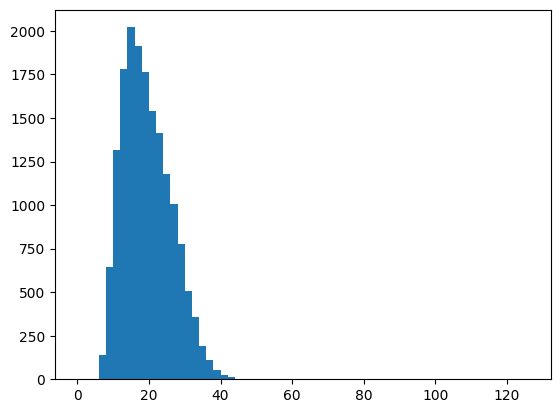

Testing Sentence Lengths: 


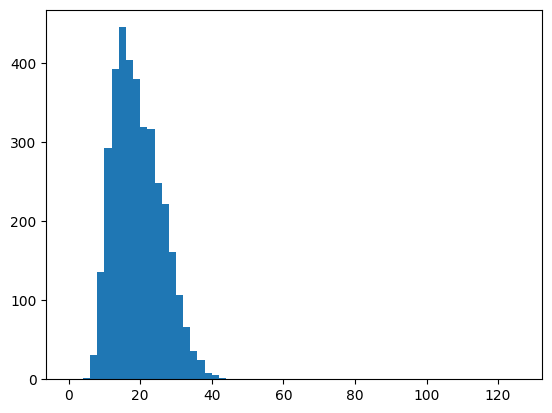

In [ ]:
print("Training Sentence Lengths: ")
plt.hist([ len(tok.tokenize(sentence)) for sentence in selected_dataset.train[DATA_COLUMN].to_list()],bins=range(0,128,2))
plt.show()

print("Testing Sentence Lengths: ")
plt.hist([ len(tok.tokenize(sentence)) for sentence in selected_dataset.test[DATA_COLUMN].to_list()],bins=range(0,128,2))
plt.show()

Let's select 100 as our maximum sentence length, and check how many sequences will be truncated

In [ ]:
max_len = 128

In [ ]:
print("Truncated training sequences: ", sum([len(tok.tokenize(sentence)) > max_len for sentence in selected_dataset.test[DATA_COLUMN].to_list()]))

print("Truncated testing sequences: ", sum([len(tok.tokenize(sentence)) > max_len for sentence in selected_dataset.test[DATA_COLUMN].to_list()]))

Truncated training sequences:  0
Truncated testing sequences:  0


8 out of ~4000 for testing isn't bad

Now let's create a classification dataset to load the data

In [ ]:
class ClassificationDataset(Dataset):
    def __init__(self, text, target, model_name, max_len, label_map):
      super(ClassificationDataset).__init__()
      """
      Args:
      text (List[str]): List of the training text
      target (List[str]): List of the training labels
      tokenizer_name (str): The tokenizer name (same as model_name).
      max_len (int): Maximum sentence length
      label_map (Dict[str,int]): A dictionary that maps the class labels to integer
      """
      self.text = text
      self.target = target
      self.tokenizer_name = model_name
      self.tokenizer = AutoTokenizer.from_pretrained(model_name)
      self.max_len = max_len
      self.label_map = label_map


    def __len__(self):
      return len(self.text)

    def __getitem__(self,item):
      text = str(self.text[item])
      text = " ".join(text.split())

      inputs = self.tokenizer(
          text,
          max_length=self.max_len,
          padding='max_length',
          truncation=True
      )
      return InputFeatures(**inputs,label=self.label_map[self.target[item]])

In [ ]:
label_map = { v:index for index, v in enumerate(selected_dataset.label_list) }
print(label_map)

train_dataset = ClassificationDataset(
    selected_dataset.train[DATA_COLUMN].to_list(),
    selected_dataset.train[LABEL_COLUMN].to_list(),
    model_name,
    max_len,
    label_map
  )
val_dataset = ClassificationDataset(
    selected_dataset.val[DATA_COLUMN].to_list(),
    selected_dataset.val[LABEL_COLUMN].to_list(),
    model_name,
    max_len,
    label_map
  )

{'negative': 0, 'neutral': 1, 'positive': 2}


Check the dataset output

In [ ]:
print(next(iter(train_dataset)))

InputFeatures(input_ids=[2, 37, 647, 24464, 17987, 2052, 4709, 1025, 195, 647, 38676, 209, 11686, 5852, 183, 22514, 209, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], attention_mask=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], token_type_ids=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

Create a function that return a pretrained model ready to do classification

In [ ]:
!pip install -q adapters

In [ ]:
from adapters import AutoAdapterModel

def model_init():
    return AutoAdapterModel.from_pretrained(model_name, return_dict=True)

Define whatever metric you want here

In [ ]:
from transformers import EvalPrediction

def compute_accuracy(p: EvalPrediction):
  preds = np.argmax(p.predictions, axis=1)
  return {"acc": (preds == p.label_ids).mean()}

In [ ]:
# Set random seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

#Regular Training

Define our training parameters.
Check the TrainingArguments documentation for more options https://huggingface.co/transformers/main_classes/trainer.html#trainingarguments

In [ ]:
# Set up training arguments
training_args = TrainingArguments(
    learning_rate=5e-5,
    num_train_epochs=5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    logging_steps=200,
    output_dir="./training_output",
    overwrite_output_dir=True,
   remove_unused_columns=False,
    report_to='none'
)

set_seed(training_args.seed)

Create the trainer

In [ ]:
model = model_init()

# Add a new adapter and activate it
adapter_name = "general_adapter"

# Add adapter, activate, and add classification head
model.add_adapter(adapter_name)
model.train_adapter(adapter_name)
model.set_active_adapters(adapter_name)
model.add_classification_head(adapter_name, num_labels=len(label_map))

In [ ]:
from adapters import AdapterTrainer

trainer = AdapterTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_accuracy,
)

In [ ]:
# Start the training
trainer.train()

Step,Training Loss
200,0.574400
400,0.412500
600,0.371400
800,0.369900
1000,0.357700
1200,0.341500
1400,0.332200
1600,0.343200
1800,0.319900
2000,0.332400


TrainOutput(global_step=2625, training_loss=0.3626527844383603, metrics={'train_runtime': 306.0111, 'train_samples_per_second': 273.993, 'train_steps_per_second': 8.578, 'total_flos': 5653067424165120.0, 'train_loss': 0.3626527844383603, 'epoch': 5.0})

In [ ]:
# Start the training
trainer.train()

Save the model, the tokenizer and the config

In [ ]:
inv_label_map = inv_label_map = { v:k for k, v in label_map.items()}
print(inv_label_map)
trainer.model.config.label2id = label_map
trainer.model.config.id2label = inv_label_map
trainer.save_model("output_dir")
train_dataset.tokenizer.save_pretrained("output_dir")
# Save only the adapter (not the full model)
model.save_adapter("output_dir/general_adapter", 'general_adapter')

{0: 'negative', 1: 'neutral', 2: 'positive'}


# For Climate

In [ ]:
data = pd.read_excel('All Climate Change Data - All Related.xlsx')

data.drop_duplicates(subset='text', inplace = True)
data.dropna(inplace = True, subset='text')
data.reset_index(drop=True, inplace = True)

data = data.rename(columns={'text':'Text', 'Final Label':'sentiment'})
data = data[['Text', 'sentiment']]
data['sentiment'] = data['sentiment'].str.lower()
data.columns = [DATA_COLUMN, LABEL_COLUMN]
print(data[LABEL_COLUMN].value_counts())

sentiment
neutral     10307
negative     8140
positive     5510
Name: count, dtype: int64


In [ ]:
data[DATA_COLUMN] = data[DATA_COLUMN].str.replace(r'[^\w\s]+', '')
data[DATA_COLUMN] = data[DATA_COLUMN].str.replace("\s+", " ", regex=True)

data[DATA_COLUMN] = data[DATA_COLUMN].apply(normalize_arabic)
data[DATA_COLUMN] = data[DATA_COLUMN].apply(remove_ids)

data.head()

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1950/2797559622.py:2: SyntaxWarning: invalid escape sequence '\s'
  data[DATA_COLUMN] = data[DATA_COLUMN].str.replace("\s+", " ", regex=True)


,Text,sentiment
0,هذه ال٢.٥٪ لا تنطلق الى الفضاء الكوني فتحتبس و...,negative
1,#عاجل | ادارة الكوارث والطوارئ التركية: ازالة ...,neutral
2,RT @USUN: عُقد في مالطا هذا الاسبوع اول اجتماع...,neutral
3,رغم ارتفاع درجات الحرارة واشعة الشمس اللاهبة و...,positive
4,قبل ايام تم استضافتي لتسجيل بودكاست بحكم اختصا...,neutral


In [ ]:
data[DATA_COLUMN] = data_cleaning(data[DATA_COLUMN])

In [ ]:
data.dropna(inplace = True)
data = data.drop_duplicates(subset = DATA_COLUMN)
data.shape[0]

23955

In [ ]:
indecies = pd.read_csv('Train-Val-Test-Indecies-Climate.csv')

# Clean and convert to integer index arrays
test = data.loc[indecies['test'].dropna().astype(int).values]
train = data.loc[indecies['train'].dropna().astype(int).values]
val = data.loc[indecies['val'].dropna().astype(int).values]

In [ ]:
data = CustomDataset("Collected", train, val, test, label_list)
all_datasets.append(data)

In [ ]:
for x in all_datasets:
  print(x.name)

Climate
Collected


In [ ]:
dataset = all_datasets[1]

In [ ]:
dataset.train[DATA_COLUMN] = dataset.train[DATA_COLUMN].apply(lambda x: arabic_prep.preprocess(x))
dataset.test[DATA_COLUMN] = dataset.test[DATA_COLUMN].apply(lambda x: arabic_prep.preprocess(x))
dataset.val[DATA_COLUMN] = dataset.val[DATA_COLUMN].apply(lambda x: arabic_prep.preprocess(x))

In [ ]:
dataset.val['sentiment'].value_counts()

,count
sentiment,
neutral,1546
negative,1221
positive,827


In [ ]:
train_collected = ClassificationDataset(
    dataset.train[DATA_COLUMN].to_list(),
    dataset.train[LABEL_COLUMN].to_list(),
    model_name,
    max_len,
    label_map
  )
val_collected = ClassificationDataset(
    dataset.val[DATA_COLUMN].to_list(),
    dataset.val[LABEL_COLUMN].to_list(),
    model_name,
    max_len,
    label_map
  )

In [ ]:
model2 = model_init()

# Add a new adapter and activate it
adapter_name2 = "climate_adapter"

# Add adapter, activate, and add classification head
model2.add_adapter(adapter_name2)
model2.train_adapter(adapter_name2)
model2.set_active_adapters(adapter_name2)
model2.add_classification_head(adapter_name2, num_labels=len(label_map))

In [ ]:
trainer2 = AdapterTrainer(
    model=model2,
    args=training_args,
    train_dataset=train_collected,
    eval_dataset=val_collected,
    compute_metrics=compute_accuracy,
)

In [ ]:
trainer2.train()

Step,Training Loss
200,0.778500
400,0.625800
600,0.613100
800,0.606700
1000,0.588400
1200,0.578800
1400,0.578300
1600,0.565900
1800,0.566400
2000,0.563600


TrainOutput(global_step=2625, training_loss=0.593822020031157, metrics={'train_runtime': 311.7913, 'train_samples_per_second': 268.914, 'train_steps_per_second': 8.419, 'total_flos': 5653067424165120.0, 'train_loss': 0.593822020031157, 'epoch': 5.0})

In [ ]:
inv_label_map = inv_label_map = { v:k for k, v in label_map.items()}
print(inv_label_map)
trainer2.model.config.label2id = label_map
trainer2.model.config.id2label = inv_label_map
trainer2.save_model("climate_dir")
train_collected.tokenizer.save_pretrained("climate_dir")
# Save only the adapter (not the full model)
model2.save_adapter("climate_dir/climate_adapter", 'climate_adapter')

{0: 'negative', 1: 'neutral', 2: 'positive'}


# predict on ASAD

In [ ]:
from adapters import Fuse

model2.load_adapter("climate_dir/climate_adapter")
model2.load_adapter("output_dir/general_adapter")

adapter_setup = Fuse("climate_adapter", "general_adapter")
model2.add_adapter_fusion(adapter_setup)
model2.set_active_adapters(adapter_setup)
model2.train_adapter_fusion(adapter_setup)

In [ ]:
pred_df = pd.DataFrame()
pred_df['text'] = selected_dataset.test[DATA_COLUMN].values

In [ ]:
import torch

def predict(premise):
  encoded = tok(premise, return_tensors="pt")
  if torch.cuda.is_available():
    encoded.to("cuda")
    model2.to("cuda")
  logits = model2(**encoded)[0]
  pred_class = torch.argmax(logits).item()
  return pred_class

pred = []
for text in pred_df['text']:
  pred.append(predict(text))

In [ ]:
id2label = {v: k for k, v in label_map.items()}

# Convert numeric predictions to string labels
string_labels = [id2label[pr] for pr in pred]

In [ ]:
pred_df[f'Final Prediction'] = string_labels
pred_df[f'Final Prediction'].value_counts()

,count
Final Prediction,
neutral,2276
negative,825
positive,493


In [ ]:
print(classification_report(selected_dataset.test[LABEL_COLUMN],pred_df['Final Prediction'], digits=4))

              precision    recall  f1-score   support

    negative     0.5431    0.7449    0.6282       584
     neutral     0.8432    0.7769    0.8087      2443
    positive     0.6199    0.5926    0.6060       567

    accuracy                         0.7426      3594
   macro avg     0.6687    0.7048    0.6809      3594
weighted avg     0.7592    0.7426    0.7474      3594



# Pred on Collected

In [ ]:
pred_df = pd.DataFrame()
pred_df['text'] = dataset.test[DATA_COLUMN].values

In [ ]:
pred = []
for text in pred_df['text']:
  pred.append(predict(text))

In [ ]:
string_labels = [id2label[pr] for pr in pred]

In [ ]:
dataset.test[LABEL_COLUMN].value_counts()

,count
sentiment,
neutral,1547
negative,1221
positive,826


In [ ]:
pred_df[f'Final Prediction'] = string_labels
pred_df[f'Final Prediction'].value_counts()

,count
Final Prediction,
neutral,1670
negative,1185
positive,739


In [ ]:
print(classification_report(dataset.test[LABEL_COLUMN],pred_df['Final Prediction'], digits=4))

              precision    recall  f1-score   support

    negative     0.7560    0.7002    0.7270      1221
     neutral     0.6673    0.7264    0.6956      1546
    positive     0.7603    0.7170    0.7380       827

    accuracy                         0.7154      3594
   macro avg     0.7278    0.7146    0.7202      3594
weighted avg     0.7188    0.7154    0.7160      3594

